In [1]:
import numpy as np

# Array sin outliers
data_normal = np.array([10, 12, 11, 13, 12, 14, 10, 11, 13])

# Array con outliers
data_outliers = np.array([10, 12, 1169, 13, 12, 14, 10, 11, 13, 2000])


## Medidas centrales de los datos sin grandes outliers

In [6]:
np.mean(data_normal)

np.float64(11.777777777777779)

In [7]:
np.median(data_normal)

np.float64(12.0)

## Medidas centrales de los datos con grandes outliers

In [8]:
np.mean(data_outliers)

np.float64(30.6)

In [9]:
np.median(data_outliers)

np.float64(12.0)

Se observa q en la lista de numeros con grandes outliers hay una diferencia notable entre ambas medidas

In [10]:
import pandas as pd

In [11]:
df = pd.read_csv('Housing.csv')

In [16]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [17]:
df.shape

(545, 13)

In [15]:
df.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

In [19]:
cualitativas = df.select_dtypes(include='object')

In [20]:
cuantitativas = df.select_dtypes(include='int64')

In [22]:
cuantitativas.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

In [57]:
discretas = ('bedrooms',	'bathrooms',	'stories',	'parking')
continuas = ('price',	'area')

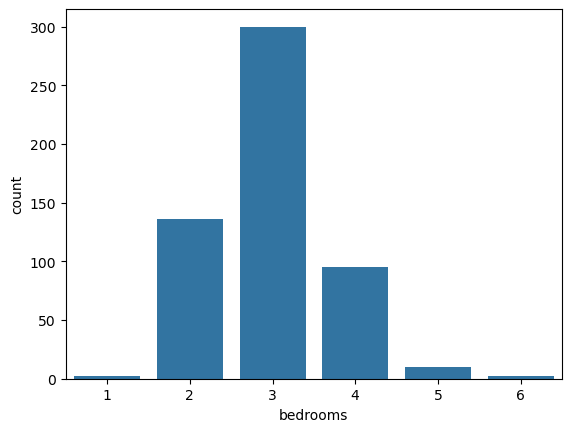

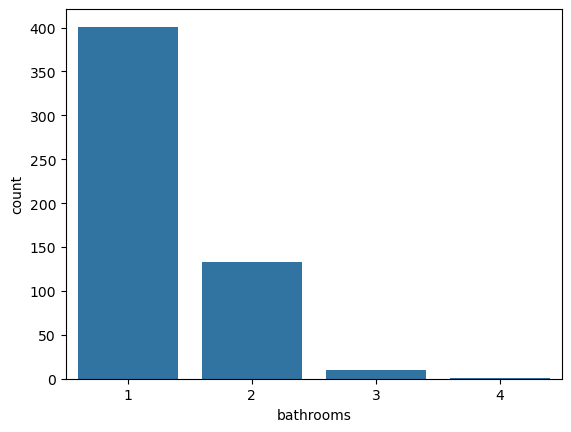

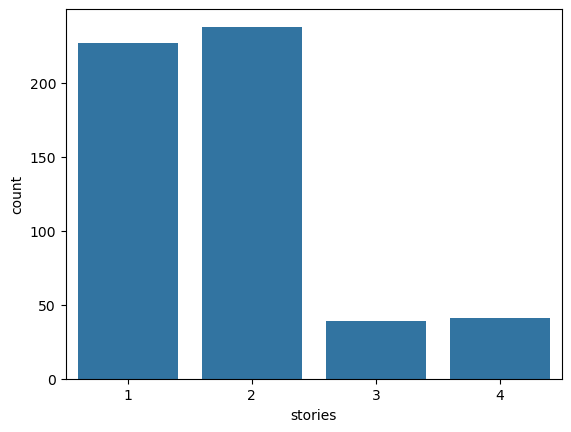

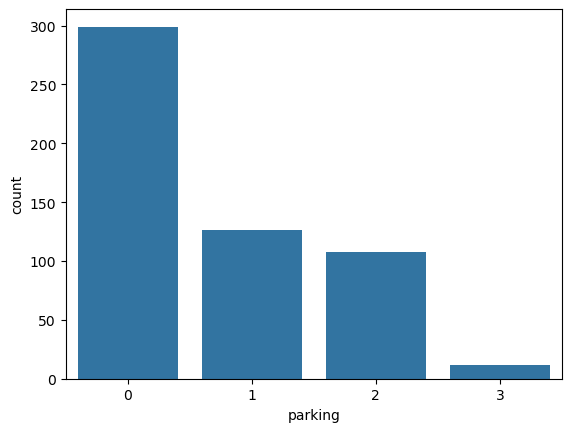

In [41]:
for col in ('bedrooms',	'bathrooms',	'stories',	'parking'):
    sns.countplot(data=cuantitativas, x=col)
    plt.show()


In [104]:
def encontrar_outliers(col):
    Q1 = cuantitativas[col].quantile(0.25)
    Q3 = cuantitativas[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Límites inferior y superior
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # Detectar outliers
    outliers_iqr = cuantitativas[
        (cuantitativas[col] < limite_inferior) |
        (cuantitativas[col] > limite_superior)
    ]
    if col in discretas:
        sns.countplot(data=cuantitativas, x=col)
        plt.show()
        print("Outliers con IQR: ", col)
        print(outliers_iqr[col].value_counts())
    else:
        sns.histplot(data=cuantitativas, x=col, bins=10)
        #plt.show()
        # Obtener bins
        counts, bin_edges = np.histogram(cuantitativas[col], bins=10)
        #print(bin_edges)
        
        print("Outliers con IQR en", col)
        print(outliers_iqr[col].values)
        limite_outlier = list(outliers_iqr[col])[-1]
        plt.axvline( limite_outlier, color='red')
        plt.text(x=limite_outlier, y=50, s=limite_outlier, color='red')
        plt.show()

Outliers con IQR en price
[13300000 12250000 12250000 12215000 11410000 10850000 10150000 10150000
  9870000  9800000  9800000  9681000  9310000  9240000  9240000]


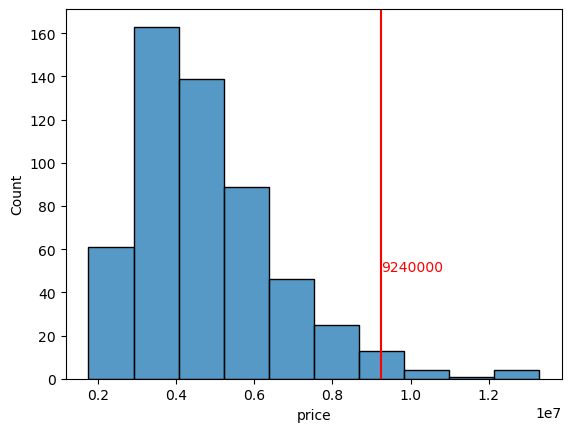

Outliers con IQR en area
[16200 13200 11440 11175 13200 12090 15600 11460 11410 10700 12900 12944]


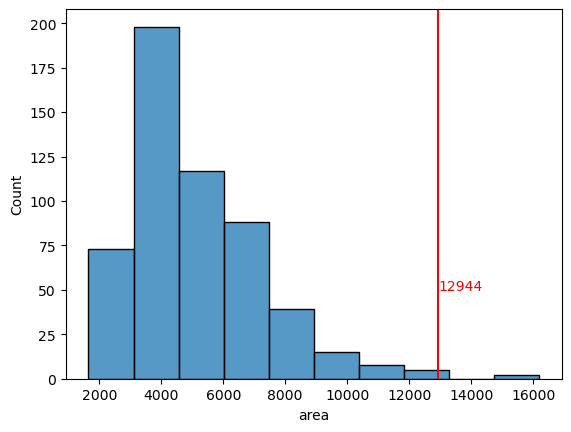

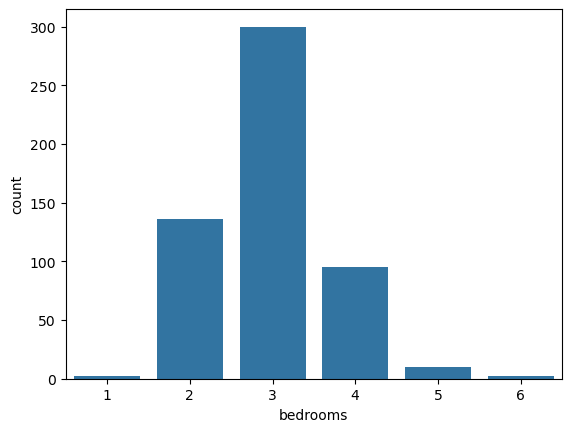

Outliers con IQR:  bedrooms
bedrooms
5    10
6     2
Name: count, dtype: int64


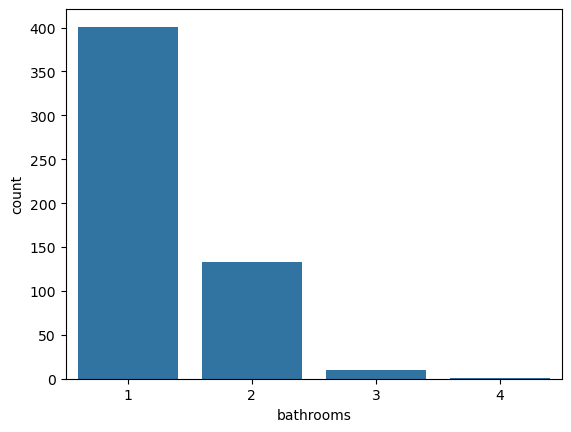

Outliers con IQR:  bathrooms
bathrooms
4    1
Name: count, dtype: int64


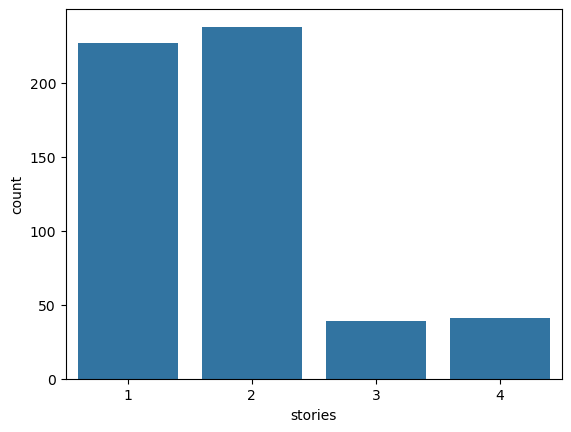

Outliers con IQR:  stories
stories
4    41
Name: count, dtype: int64


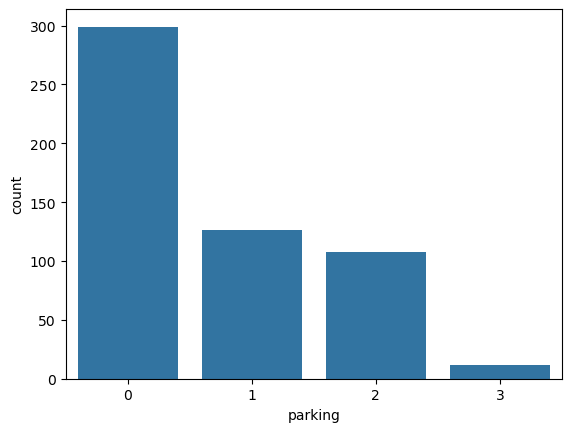

Outliers con IQR:  parking
parking
3    12
Name: count, dtype: int64


In [105]:
for col_name in cuantitativas.columns:
    encontrar_outliers(col_name)

In [44]:
cuantitativas.parking.value_counts()

parking
0    299
1    126
2    108
3     12
Name: count, dtype: int64